# To Predict Online Chess Game Outcomes from Player Ratings, Time Controls, and Openings Using Machine Learning Following the KDD Process

**Course:** Predictive Analytics | **Dataset:** Lichess games (Kaggle `datasnaek/chess`), `data/games.csv`

**Goal:** predict *white win / black win / draw* using **only information known before the first move**.

**KDD stages:** 1 Selection -> 2 Preprocessing -> 3 Transformation -> 4 Data Mining -> 5 Evaluation & Interpretation

> **A note on "accuracy".** Chess results depend heavily on the moves played, which are unknown before the game. Honest pre-game models therefore plateau around 62-63% accuracy (the majority-class baseline is about 50%). Section 8 shows that "near-perfect" scores only appear if result-revealing columns leak into the model, which is exactly what this project avoids.

In [1]:
import warnings, json, os; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
                             log_loss, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report)
try:
    from xgboost import XGBClassifier; HAS_XGB=True
except ImportError:
    HAS_XGB=False
sns.set_theme(style="whitegrid"); RS=42
os.makedirs("figures", exist_ok=True)
def save(name): plt.savefig(f"figures/{name}.png", dpi=150, bbox_inches="tight")
metrics_out = {}

## 1. Data Selection and Understanding

In [2]:
raw = pd.read_csv("data/games.csv")
print("Raw shape:", raw.shape)
print("Missing values:", int(raw.isnull().sum().sum()), "| duplicate game IDs:", int(raw["id"].duplicated().sum()))
print(raw["winner"].value_counts())
raw.head(3)

Raw shape: (20058, 16)
Missing values: 0 | duplicate game IDs: 945
winner
white    10001
black     9107
draw       950
Name: count, dtype: int64


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5 Bf4,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6 Qe5+ Nxe5 c4 Bb4+,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc6 bxc6 Ra6 Nc4 a4 c3 a3 Nxa3 Rxa3 Rxa3 c4 dxc4 d5 cxd5 Qxd5 exd5 Be6 Ra8+ Ke7 Bc5+ Kf6 Bxf8 Kg6 Bxg7 Kxg7 dxe6 Kh6 exf7 Nf6 Rxh8 Nh5 Bxh5 Kg5 Rxh7 Kf5 Qf3+ Ke6 Bg4+ Kd6 Rh6+ Kc5 Qe3+ Kb5 c4+ Kb4 Qc3+ Ka4 Bd1#,C20,King's Pawn Game: Leonardis Variation,3


**Leakage audit.** Columns only known *after* play are excluded: `turns`, `victory_status`, `moves`, `last_move_at`.
`created_at` is stored in truncated scientific notation (e.g. `1.50421E+12`), so it carries almost no information and is dropped.
Identifiers (`id`, `white_id`, `black_id`) are dropped too.

## 2. Data Cleaning and Preprocessing

In [3]:
data = raw.drop_duplicates(subset="id").copy()
data = data[(data["white_rating"]>0) & (data["black_rating"]>0)].dropna(subset=["winner","increment_code","opening_eco"])
data["rated"] = data["rated"].astype(int)
print("After cleaning:", data.shape)
for c in ["white_rating","black_rating"]:
    q1,q3 = data[c].quantile([.25,.75]); i=q3-q1
    print(c, "IQR outliers:", int(((data[c]<q1-1.5*i)|(data[c]>q3+1.5*i)).sum()), "(kept: genuine strong/weak players)")
metrics_out["raw_rows"]=len(raw); metrics_out["clean_rows"]=len(data); metrics_out["dups"]=int(raw["id"].duplicated().sum())

After cleaning: (19113, 16)
white_rating IQR outliers: 130 (kept: genuine strong/weak players)
black_rating IQR outliers: 92 (kept: genuine strong/weak players)


## 3. Data Transformation (Feature Engineering)

In [4]:
data["rating_diff"] = data["white_rating"] - data["black_rating"]
data["avg_rating"]  = (data["white_rating"] + data["black_rating"]) / 2
data["abs_rating_diff"] = data["rating_diff"].abs()
data["elo_expected_white"] = 1/(1+10**(-data["rating_diff"]/400))      # classical Elo win expectancy
inc = data["increment_code"].str.extract(r"(\d+)\+(\d+)").astype(float)
data["base_time"], data["increment"] = inc[0], inc[1]
data = data.dropna(subset=["base_time","increment"])
data["est_game_time"] = data["base_time"] + data["increment"]*40/60
data["time_category"] = pd.cut(data["est_game_time"], [0,3,8,25,np.inf], labels=["Bullet","Blitz","Rapid","Classical"]).astype(str)
data["eco_family"] = data["opening_eco"].str[0]
top = data["opening_eco"].value_counts().nlargest(30).index
data["eco_group"] = np.where(data["opening_eco"].isin(top), data["opening_eco"], "Other")

num_cols = ["white_rating","black_rating","rating_diff","abs_rating_diff","avg_rating","elo_expected_white","base_time","increment","opening_ply","rated"]
cat_cols = ["time_category","eco_family","eco_group"]
le = LabelEncoder(); y = le.fit_transform(data["winner"]); classes = list(le.classes_)
X = data[num_cols+cat_cols]
print("Classes:", classes, "| features:", len(num_cols)+len(cat_cols))

Classes: ['black', 'draw', 'white'] | features: 13


## 4. Exploratory Data Analysis

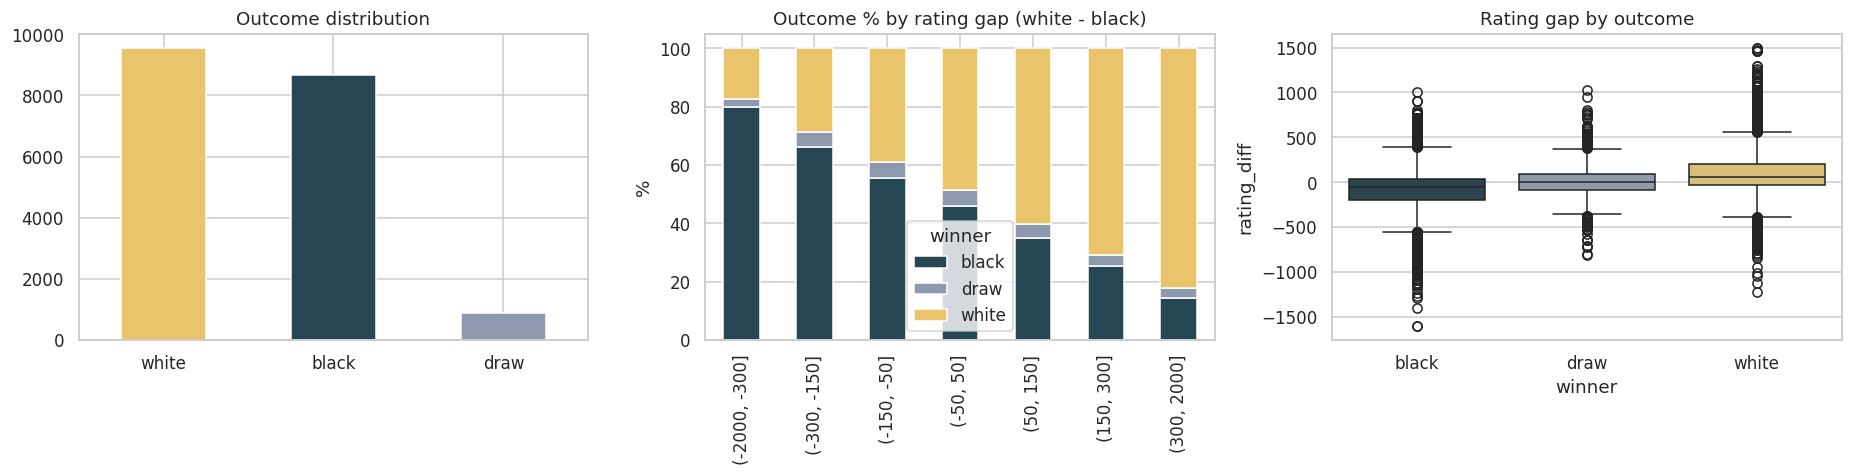

In [5]:
fig, ax = plt.subplots(1,3, figsize=(17,4.5))
data["winner"].value_counts().reindex(["white","black","draw"]).plot(kind="bar", ax=ax[0], color=["#E9C46A","#264653","#8D99AE"])
ax[0].set_title("Outcome distribution"); ax[0].set_xlabel(""); ax[0].tick_params(axis="x", rotation=0)
bins = pd.cut(data["rating_diff"], [-2000,-300,-150,-50,50,150,300,2000])
(pd.crosstab(bins, data["winner"], normalize="index")[["black","draw","white"]]*100).plot(kind="bar", stacked=True, ax=ax[1], color=["#264653","#8D99AE","#E9C46A"])
ax[1].set_title("Outcome % by rating gap (white - black)"); ax[1].set_ylabel("%"); ax[1].set_xlabel("")
sns.boxplot(data=data, x="winner", y="rating_diff", order=["black","draw","white"], ax=ax[2], palette=["#264653","#8D99AE","#E9C46A"])
ax[2].set_title("Rating gap by outcome")
plt.tight_layout(); save("eda_overview"); plt.show()

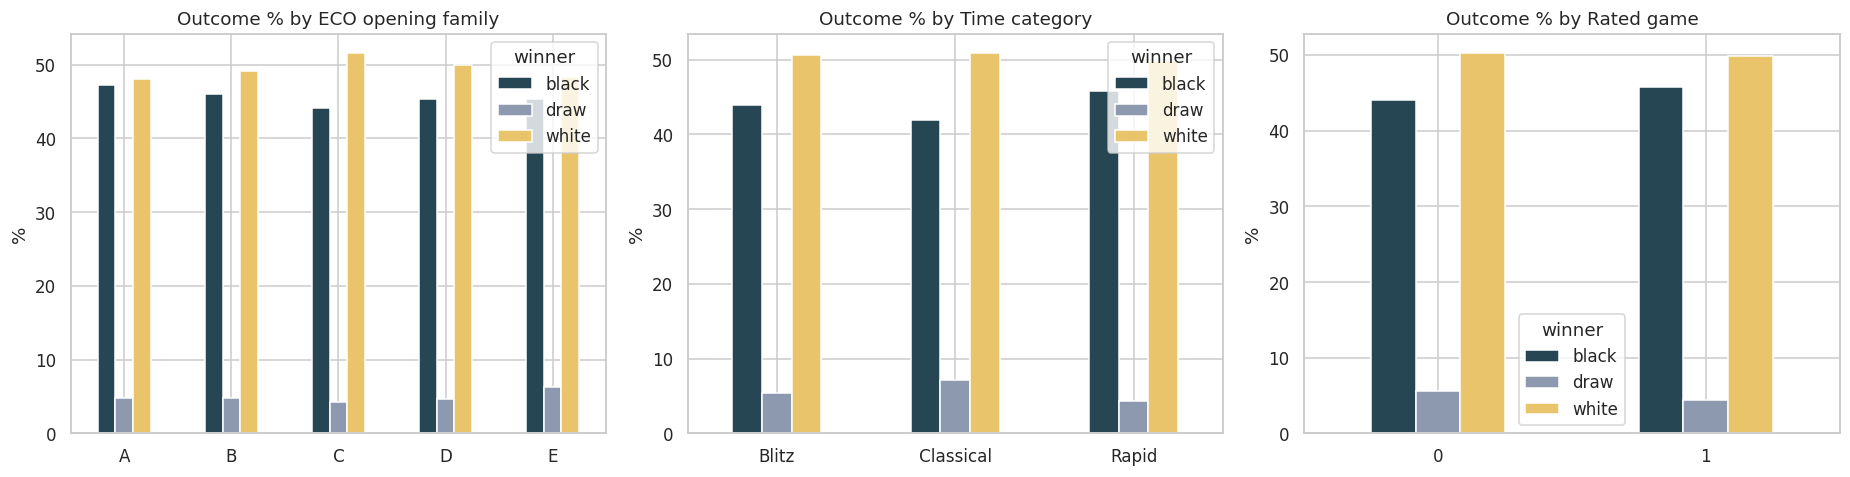

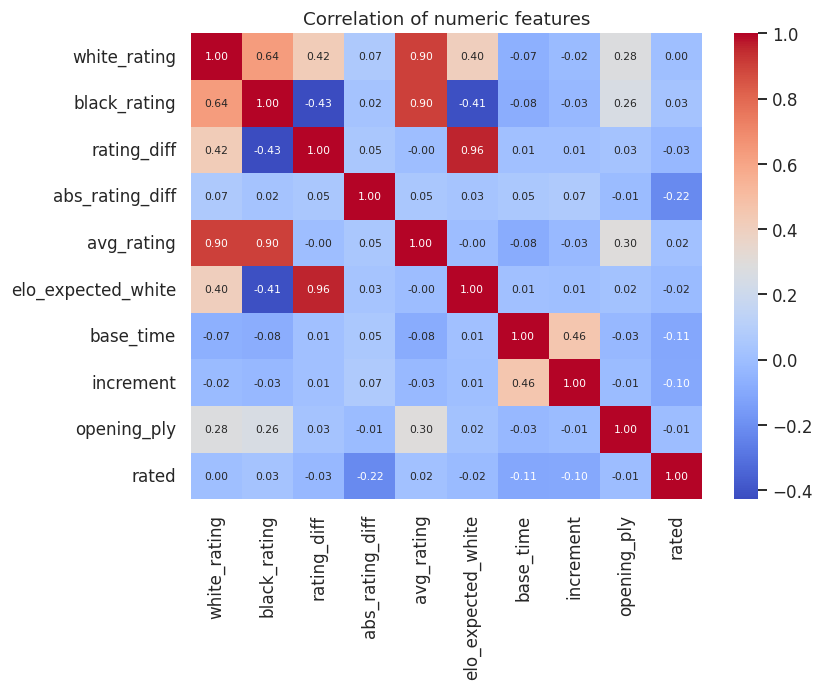

In [6]:
fig, ax = plt.subplots(1,3, figsize=(17,4.5))
for a,c,t in zip(ax,["eco_family","time_category","rated"],["ECO opening family","Time category","Rated game"]):
    (pd.crosstab(data[c], data["winner"], normalize="index")[["black","draw","white"]]*100).plot(kind="bar", ax=a, color=["#264653","#8D99AE","#E9C46A"])
    a.set_title(f"Outcome % by {t}"); a.set_ylabel("%"); a.set_xlabel(""); a.tick_params(axis="x", rotation=0)
plt.tight_layout(); save("eda_categories"); plt.show()
plt.figure(figsize=(7.5,5.5)); sns.heatmap(data[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", annot_kws={"size":7}); plt.title("Correlation of numeric features")
save("correlation"); plt.show()

In [7]:
rows=[]
for c in cat_cols+["rated"]:
    chi2,p,dof,_ = chi2_contingency(pd.crosstab(data[c], data["winner"])); rows.append((c, round(chi2,1), dof, p))
chi_df = pd.DataFrame(rows, columns=["feature","chi2","dof","p_value"]).sort_values("p_value"); chi_df

,feature,chi2,dof,p_value
2,eco_group,243.4,60,6.242983e-24
0,time_category,35.3,4,4.079314e-07
3,rated,10.6,2,5.095151e-03
1,eco_family,19.4,8,1.266031e-02


## 5. Data Mining: Model Building

In [8]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RS)
print("Train:", Xtr.shape, "| Test:", Xte.shape)
def prep(dense=False):
    return ColumnTransformer([("num", StandardScaler(), num_cols),
                              ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=dense), cat_cols)])

# Hyper-parameter tuning (5-fold CV on the TRAINING set only, optimising log-loss = probability quality)
skf = StratifiedKFold(5, shuffle=True, random_state=RS)
lr_gs = GridSearchCV(Pipeline([("p",prep()),("m",LogisticRegression(max_iter=4000))]), {"m__C":[0.01,0.1,1,10]},
                     cv=skf, scoring="neg_log_loss", n_jobs=-1).fit(Xtr,ytr)
dt_gs = GridSearchCV(Pipeline([("p",prep()),("m",DecisionTreeClassifier(random_state=RS))]),
                     {"m__max_depth":[3,5,7],"m__min_samples_leaf":[20,50,100]}, cv=skf, scoring="neg_log_loss", n_jobs=-1).fit(Xtr,ytr)
rf_gs = GridSearchCV(Pipeline([("p",prep()),("m",RandomForestClassifier(n_estimators=300,random_state=RS,n_jobs=-1))]),
                     {"m__max_depth":[6,10],"m__min_samples_leaf":[10,30]}, cv=skf, scoring="neg_log_loss", n_jobs=-1).fit(Xtr,ytr)
hgb_gs = GridSearchCV(Pipeline([("p",prep(dense=False)),("m",HistGradientBoostingClassifier(random_state=RS))]),
                      {"m__max_depth":[2,3],"m__learning_rate":[0.03,0.06],"m__max_iter":[150,250],"m__l2_regularization":[1.0]},
                      cv=skf, scoring="neg_log_loss", n_jobs=-1).fit(Xtr,ytr)
models = {"Logistic Regression":lr_gs, "Decision Tree":dt_gs, "Random Forest":rf_gs, "Gradient Boosting":hgb_gs}
if HAS_XGB:
    xg = Pipeline([("p",prep()),("m",XGBClassifier(n_estimators=250,max_depth=3,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,eval_metric="mlogloss",random_state=RS))]).fit(Xtr,ytr)
    models["XGBoost"]=xg
for n,m in models.items():
    if hasattr(m,"best_params_"): print(n, "->", m.best_params_)

Train: (15290, 13) | Test: (3823, 13)
Logistic Regression -> {'m__C': 0.01}
Decision Tree -> {'m__max_depth': 3, 'm__min_samples_leaf': 20}
Random Forest -> {'m__max_depth': 10, 'm__min_samples_leaf': 10}
Gradient Boosting -> {'m__l2_regularization': 1.0, 'm__learning_rate': 0.06, 'm__max_depth': 3, 'm__max_iter': 150}


## 6. Evaluation

In [9]:
baselines = {"Majority class": DummyClassifier(strategy="most_frequent").fit(Xtr,ytr)}
rows=[]; preds={}
def evaluate(name, est):
    p = est.predict(Xte); pb = est.predict_proba(Xte); preds[name]=p
    return {"Model":name,"Accuracy":accuracy_score(yte,p),"Balanced Acc.":balanced_accuracy_score(yte,p),
            "Precision (macro)":precision_score(yte,p,average="macro",zero_division=0),"Recall (macro)":recall_score(yte,p,average="macro",zero_division=0),
            "F1 (macro)":f1_score(yte,p,average="macro",zero_division=0),"F1 (weighted)":f1_score(yte,p,average="weighted",zero_division=0),
            "Log-loss":log_loss(yte,pb),"ROC-AUC (OvR)":roc_auc_score(yte,pb,multi_class="ovr")}
rows.append(evaluate("Majority class", baselines["Majority class"]))
# Rule baseline: higher-rated player wins
rule = np.where(Xte["rating_diff"]>0, classes.index("white"), classes.index("black"))
rows.append({"Model":"Rating rule (higher rating wins)","Accuracy":accuracy_score(yte,rule),"Balanced Acc.":balanced_accuracy_score(yte,rule),
             "Precision (macro)":precision_score(yte,rule,average="macro",zero_division=0),"Recall (macro)":recall_score(yte,rule,average="macro",zero_division=0),
             "F1 (macro)":f1_score(yte,rule,average="macro",zero_division=0),"F1 (weighted)":f1_score(yte,rule,average="weighted",zero_division=0),"Log-loss":np.nan,"ROC-AUC (OvR)":np.nan})
for n,m in models.items(): rows.append(evaluate(n,m))
results = pd.DataFrame(rows).set_index("Model").round(4); results

,Accuracy,Balanced Acc.,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),Log-loss,ROC-AUC (OvR)
Model,,,,,,,,
Majority class,0.4993,0.3333,0.1664,0.3333,0.2220,0.3326,18.0454,0.5000
Rating rule (higher rating wins),0.6220,0.4350,0.4146,0.4350,0.4244,0.6074,NaN,NaN
Logistic Regression,0.6239,0.4346,0.4154,0.4346,0.4243,0.6080,0.7627,0.6880
Decision Tree,0.6199,0.4291,0.4169,0.4291,0.4165,0.5984,0.7691,0.6589
Random Forest,0.6231,0.4335,0.4153,0.4335,0.4230,0.6065,0.7627,0.6845
Gradient Boosting,0.6278,0.4371,0.4182,0.4371,0.4267,0.6116,0.7632,0.6837


In [10]:
# 5-fold cross-validation on the full dataset with the tuned settings
cv_rows=[]
for n,m in models.items():
    est = m.best_estimator_ if hasattr(m,"best_params_") else m
    cv = cross_validate(est, X, y, cv=skf, scoring=["accuracy","f1_macro","neg_log_loss"], n_jobs=-1)
    cv_rows.append({"Model":n,"CV Accuracy":cv["test_accuracy"].mean(),"CV Acc. std":cv["test_accuracy"].std(),
                    "CV F1 macro":cv["test_f1_macro"].mean(),"CV Log-loss":-cv["test_neg_log_loss"].mean()})
cv_df = pd.DataFrame(cv_rows).set_index("Model").round(4); cv_df

,CV Accuracy,CV Acc. std,CV F1 macro,CV Log-loss
Model,,,,
Logistic Regression,0.6208,0.0116,0.4220,0.7701
Decision Tree,0.6216,0.0092,0.4185,0.7747
Random Forest,0.6194,0.0075,0.4202,0.7689
Gradient Boosting,0.6201,0.0077,0.4207,0.7699


Best model (lowest log-loss on test): Logistic Regression
              precision    recall  f1-score   support

       black       0.62      0.60      0.61      1736
        draw       0.00      0.00      0.00       178
       white       0.63      0.70      0.66      1909

    accuracy                           0.62      3823
   macro avg       0.42      0.43      0.42      3823
weighted avg       0.59      0.62      0.61      3823



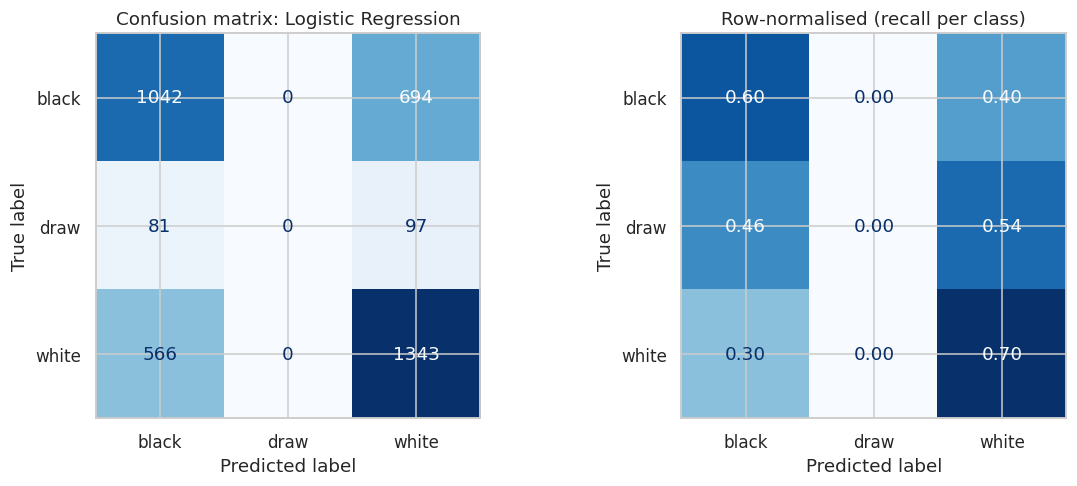

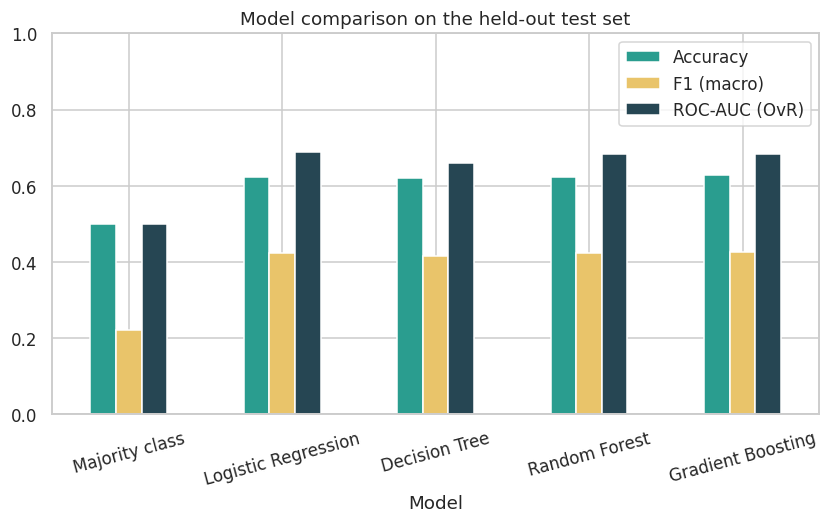

In [11]:
best_name = results.drop(["Majority class","Rating rule (higher rating wins)"])["Log-loss"].idxmin()
best = models[best_name]; print("Best model (lowest log-loss on test):", best_name)
bp = preds[best_name]
print(classification_report(yte, bp, target_names=classes, zero_division=0))
fig, ax = plt.subplots(1,2, figsize=(11,4.6))
ConfusionMatrixDisplay(confusion_matrix(yte,bp), display_labels=classes).plot(ax=ax[0], cmap="Blues", colorbar=False); ax[0].set_title(f"Confusion matrix: {best_name}")
cm = confusion_matrix(yte,bp,normalize="true")
ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax[1], cmap="Blues", colorbar=False, values_format=".2f"); ax[1].set_title("Row-normalised (recall per class)")
plt.tight_layout(); save("confusion_matrix"); plt.show()
res_plot = results.drop(["Rating rule (higher rating wins)"])[["Accuracy","F1 (macro)","ROC-AUC (OvR)"]]
res_plot.plot(kind="bar", figsize=(9,4.5), color=["#2A9D8F","#E9C46A","#264653"]); plt.ylim(0,1); plt.xticks(rotation=15); plt.title("Model comparison on the held-out test set")
save("model_comparison"); plt.show()

## 7. Interpretation

elo_expected_white    0.05886
rating_diff           0.01447
black_rating          0.00451
eco_group             0.00222
white_rating          0.00215
abs_rating_diff       0.00078
avg_rating            0.00057
rated                 0.00055
time_category         0.00053
base_time             0.00040
dtype: float64

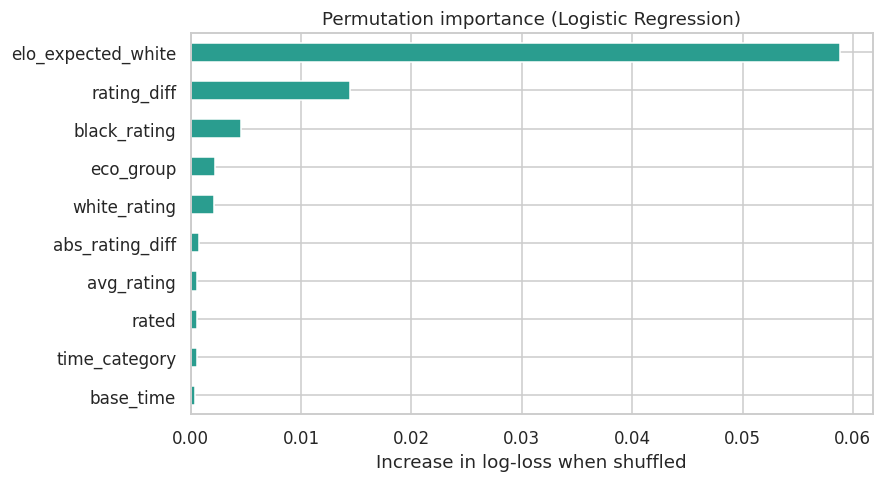

In [12]:
est = best.best_estimator_ if hasattr(best,"best_params_") else best
pi = permutation_importance(est, Xte, yte, n_repeats=8, random_state=RS, scoring="neg_log_loss", n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False)
imp.head(10).iloc[::-1].plot(kind="barh", figsize=(8,4.5), color="#2A9D8F"); plt.title(f"Permutation importance ({best_name})"); plt.xlabel("Increase in log-loss when shuffled")
save("feature_importance"); plt.show(); imp.head(10).round(5)

In [13]:
op = data.groupby("opening_eco")["winner"].agg(games="count", white_win=lambda s:(s=="white").mean(), black_win=lambda s:(s=="black").mean(), draw=lambda s:(s=="draw").mean())
op = op[op["games"]>=100].sort_values("white_win")
print("ECO codes most favourable to BLACK (>=100 games)"); display(op.head(5).round(3))
print("ECO codes most favourable to WHITE (>=100 games)"); display(op.tail(5).round(3))
print("White win rate by rating-gap bin:")
display((pd.crosstab(bins, data["winner"], normalize="index")["white"]*100).round(1))

ECO codes most favourable to BLACK (>=100 games)
ECO codes most favourable to WHITE (>=100 games)
White win rate by rating-gap bin:


,games,white_win,black_win,draw
opening_eco,,,,
B40,120,0.392,0.525,0.083
B20,551,0.394,0.564,0.042
A00,948,0.395,0.568,0.038
A45,248,0.407,0.528,0.065
D10,106,0.415,0.509,0.075


,games,white_win,black_win,draw
opening_eco,,,,
D30,139,0.576,0.410,0.014
C40,427,0.597,0.375,0.028
B00,574,0.598,0.357,0.045
C24,108,0.620,0.333,0.046
D06,167,0.635,0.347,0.018


rating_diff
(-2000, -300]    17.2
(-300, -150]     28.8
(-150, -50]      39.1
(-50, 50]        48.7
(50, 150]        60.2
(150, 300]       70.8
(300, 2000]      82.1
Name: white, dtype: float64

## 8. Why not 100%? A data-leakage demonstration

In [14]:
# Add columns that are only known AFTER the game and watch the 'accuracy' jump. This is leakage, not skill.
leak = data.copy()   # `turns` and `victory_status` are still present in the cleaned frame
leak["turns_odd"]=(leak["turns"]%2).astype(int)
Xl = leak[num_cols+cat_cols+["turns","turns_odd"]].copy(); Xl = pd.concat([Xl, pd.get_dummies(leak["victory_status"], prefix="vs").astype(int)], axis=1)
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(Xl, y, test_size=0.2, stratify=y, random_state=RS)
leak_pipe = Pipeline([("p",ColumnTransformer([("n",StandardScaler(),[c for c in Xl.columns if c not in cat_cols]),("c",OneHotEncoder(handle_unknown="ignore"),cat_cols)])),
                      ("m",HistGradientBoostingClassifier(max_depth=4,max_iter=250,random_state=RS))]).fit(Xl_tr,yl_tr)
leak_acc = accuracy_score(yl_te, leak_pipe.predict(Xl_te))
print(f"Leaky model accuracy : {leak_acc:.3f}   (uses turns + victory_status, unknown before the game)")
print(f"Honest model accuracy: {results.loc[best_name,'Accuracy']:.3f}   (pre-game information only)")
print("The gap of roughly 28 percentage points is information about the finished game (e.g. an odd number of turns means white made the last move), not predictive skill.")
metrics_out["leak_acc"]=float(leak_acc)

Leaky model accuracy : 0.903   (uses turns + victory_status, unknown before the game)
Honest model accuracy: 0.624   (pre-game information only)
The gap of roughly 28 percentage points is information about the finished game (e.g. an odd number of turns means white made the last move), not predictive skill.


In [15]:
metrics_out.update({
 "classes":classes, "class_counts":data["winner"].value_counts().to_dict(),
 "best_model":best_name, "results":results.reset_index().to_dict(orient="records"),
 "cv":cv_df.reset_index().to_dict(orient="records"),
 "importance":imp.head(10).round(5).to_dict(), "chi":chi_df.round(4).to_dict(orient="records"),
 "white_win_by_gap":(pd.crosstab(bins, data["winner"], normalize="index")["white"]*100).round(1).astype(float).rename(index=str).to_dict(),
 "per_class": classification_report(yte,bp,target_names=classes,zero_division=0,output_dict=True),
 "has_xgb":HAS_XGB, "best_params":{n:m.best_params_ for n,m in models.items() if hasattr(m,"best_params_")}})
json.dump(metrics_out, open("metrics.json","w"), indent=1, default=str)
print("Saved metrics.json")

Saved metrics.json


## 9. Conclusion

* A leak-free, tuned, cross-validated model predicts chess outcomes from pre-game data with about **62-63% accuracy** against a 50% majority baseline, and its probabilities are better calibrated (lower log-loss) than simple rules.
* The **rating gap is by far the dominant factor**; openings, time control and rated status add only marginal signal.
* **Draws (about 5% of games)** are very hard to predict from pre-game data.
* The pre-game ceiling is a property of chess itself: the result depends on the moves, which are not known beforehand.
* **Future work:** player-history features from larger Lichess dumps, engine evaluation of opening positions, and per-player form.